In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "../data/EMG_data_for_gestures-master"

def load_all_subjects(root):
    all_dfs = []
    
    COLUMNS = [
        "time",
        "channel1","channel2","channel3","channel4",
        "channel5","channel6","channel7","channel8",
        "class"
    ]

    for subject in sorted(os.listdir(root)):
        subject_path = os.path.join(root, subject)
        if not os.path.isdir(subject_path):
            continue

        for file in sorted(os.listdir(subject_path)):
            if file.endswith(".txt"):
                df = pd.read_csv(
                    os.path.join(subject_path, file),
                    sep="\t",
                    header=None,
                    skiprows=1
                )
                df.columns = COLUMNS
                df["subject"] = subject
                all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

data = load_all_subjects(DATA_ROOT)

# Clean labels
data = data.dropna(subset=["class"])
data["class"] = data["class"].astype(int)

print("Total samples:", len(data))

Total samples: 4237907


In [2]:
# Step 2: Windowing (250 ms, majority vote)

CHANNELS = [
    "channel1","channel2","channel3","channel4",
    "channel5","channel6","channel7","channel8"
]

WINDOW_SIZE = 250
STEP_SIZE = 250  # non-overlapping

def window_per_subject(data):
    windows = []
    labels = []
    subjects = []

    for subject in np.unique(data["subject"]):
        df_sub = data[data["subject"] == subject]

        start = 0
        while start + WINDOW_SIZE <= len(df_sub):
            window = df_sub.iloc[start:start + WINDOW_SIZE]

            label = window["class"].mode()[0]

            windows.append(window[CHANNELS].values)
            labels.append(label)
            subjects.append(subject)

            start += WINDOW_SIZE

    return np.array(windows), np.array(labels), np.array(subjects)

X_w, y_w, subj_w = window_per_subject(data)

print("Total windows:", len(y_w))
print("Window shape:", X_w.shape)


Total windows: 16934
Window shape: (16934, 250, 8)


Window-level label counts:
0    10880
1     1004
2      980
3      997
4     1005
5     1005
6     1009
7       54
Name: count, dtype: int64


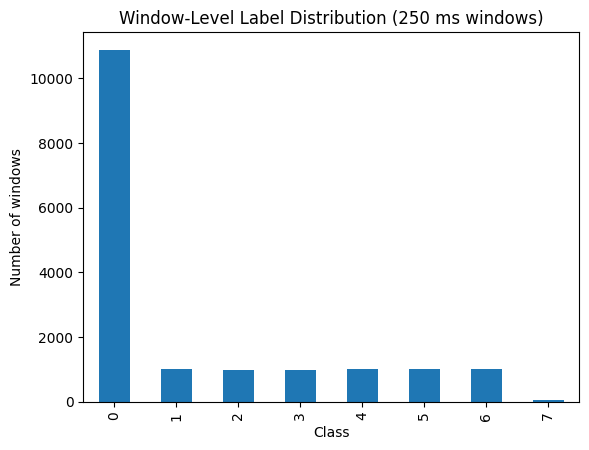

In [3]:
# Step 2.1: Window-level label distribution

import pandas as pd
import matplotlib.pyplot as plt

window_label_counts = pd.Series(y_w).value_counts().sort_index()

print("Window-level label counts:")
print(window_label_counts)

window_label_counts.plot(kind="bar")
plt.title("Window-Level Label Distribution (250 ms windows)")
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.show()


In [4]:
# Step 3: Define 2-class task (Rest vs Active)

# Keep only classes 1–6
mask_binary = np.isin(y_w, [1, 2, 3, 4, 5, 6])

X_bin = X_w[mask_binary]
y_bin_original = y_w[mask_binary]
subj_bin = subj_w[mask_binary]

# Relabel:
# 0 → Rest (original class 1)
# 1 → Active (original classes 2–6)
y_bin = np.where(y_bin_original == 1, 0, 1)

print("Total windows in binary task:", len(y_bin))

# Report class balance
class_counts = pd.Series(y_bin).value_counts().sort_index()
print("\nClass balance (Binary Task):")
print("0 (Rest):   ", class_counts.get(0, 0))
print("1 (Active): ", class_counts.get(1, 0))



Total windows in binary task: 6000

Class balance (Binary Task):
0 (Rest):    1004
1 (Active):  4996


In [5]:
# Step 4: Feature extraction (RMS + MAV)

def extract_rms_mav(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        mav = np.mean(np.abs(w), axis=0)
        features.append(np.concatenate([rms, mav]))
    return np.array(features)

X_bin_features = extract_rms_mav(X_bin)

print("Binary feature matrix shape:", X_bin_features.shape)


Binary feature matrix shape: (6000, 16)


In [6]:
# Step 5: Subject-wise split (binary task)

unique_subjects_bin = np.unique(subj_bin)
print("Total subjects:", len(unique_subjects_bin))
print("Subjects:", unique_subjects_bin)

# Hold out last 3 subjects for testing
test_subjects_bin = unique_subjects_bin[-3:]
print("Test subjects:", test_subjects_bin)

train_mask_bin = ~np.isin(subj_bin, test_subjects_bin)
test_mask_bin  =  np.isin(subj_bin, test_subjects_bin)

X_train_bin = X_bin_features[train_mask_bin]
y_train_bin = y_bin[train_mask_bin]

X_test_bin  = X_bin_features[test_mask_bin]
y_test_bin  = y_bin[test_mask_bin]

print("\nTrain samples:", len(y_train_bin))
print("Test samples :", len(y_test_bin))


Total subjects: 36
Subjects: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '15' '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '30' '31' '32' '33' '34' '35' '36']
Test subjects: ['34' '35' '36']

Train samples: 5515
Test samples : 485


In [7]:
# Step 6: Scaling (binary task)

from sklearn.preprocessing import StandardScaler

scaler_bin = StandardScaler()

X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled  = scaler_bin.transform(X_test_bin)

print("Scaled train mean (first 5 features):", X_train_bin_scaled.mean(axis=0)[:5])
print("Scaled train std  (first 5 features):", X_train_bin_scaled.std(axis=0)[:5])



Scaled train mean (first 5 features): [-1.38794989e-15  3.54037339e-15  4.18381960e-15 -4.52991125e-15
 -7.45168005e-16]
Scaled train std  (first 5 features): [1. 1. 1. 1. 1.]


In [8]:
# Step 7: Train binary Logistic Regression

from sklearn.linear_model import LogisticRegression

clf_bin = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1
)

clf_bin.fit(X_train_bin_scaled, y_train_bin)

print("Binary Logistic Regression training complete.")


Binary Logistic Regression training complete.


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [9]:
# Step 8: Evaluation (binary task)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_bin = clf_bin.predict(X_test_bin_scaled)

accuracy_bin = accuracy_score(y_test_bin, y_pred_bin)
macro_f1_bin = f1_score(y_test_bin, y_pred_bin, average="macro")
precision_bin = precision_score(y_test_bin, y_pred_bin)
recall_bin = recall_score(y_test_bin, y_pred_bin)

print(f"Accuracy      : {accuracy_bin:.4f}")
print(f"Macro F1      : {macro_f1_bin:.4f}")
print(f"Precision     : {precision_bin:.4f}")
print(f"Recall        : {recall_bin:.4f}")


Accuracy      : 0.9979
Macro F1      : 0.9963
Precision     : 1.0000
Recall        : 0.9975



Classification Report (Binary Task):
              precision    recall  f1-score   support

    Rest (0)       0.99      1.00      0.99        82
  Active (1)       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       0.99      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485



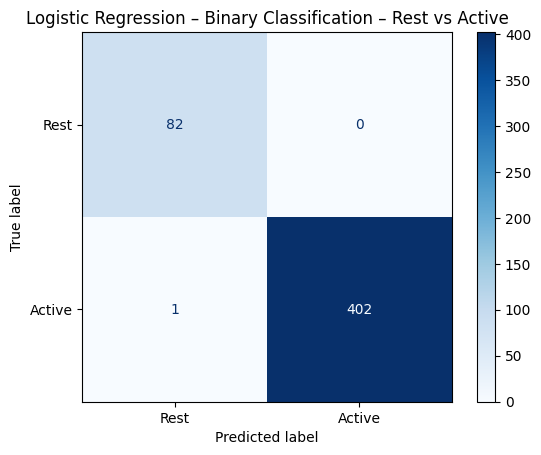

In [10]:
# Step 9: Binary Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


LR_report = classification_report(y_test_bin, y_pred_bin, target_names=["Rest (0)", "Active (1)"])
print("\nClassification Report (Binary Task):")
print(LR_report)

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["Rest", "Active"])

disp_bin.plot(cmap="Blues")
plt.title("Logistic Regression – Binary Classification – Rest vs Active")
plt.show()


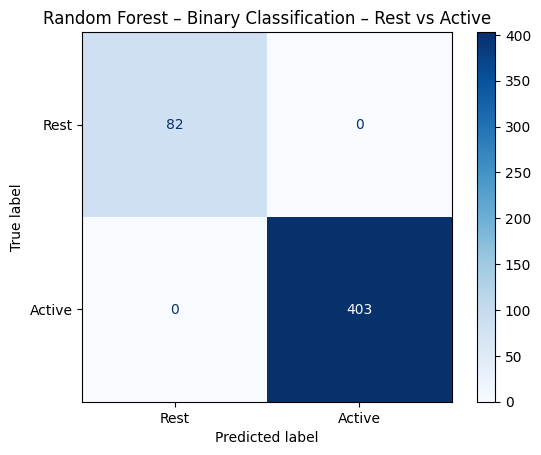

Random Forest Accuracy: 1.0000
Random Forest Macro F1: 1.0000
Random Forest Precision: 1.0000
Random Forest Recall: 1.0000
Confusion Matrix:
[[ 82   0]
 [  0 403]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       1.00      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485



In [11]:
# step 10 Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf_model_bin = RandomForestClassifier(n_estimators=20, random_state=42)
rf_model_bin.fit(X_train_bin_scaled, y_train_bin)
y_pred_rf_bin = rf_model_bin.predict(X_test_bin_scaled)
accuracy_rf_bin = accuracy_score(y_test_bin, y_pred_rf_bin)
f1_rf_bin = f1_score(y_test_bin, y_pred_rf_bin, average="macro")
precision_rf_bin = precision_score(y_test_bin, y_pred_rf_bin)
recall_rf_bin = recall_score(y_test_bin, y_pred_rf_bin)
cm_rf_bin = confusion_matrix(y_test_bin, y_pred_rf_bin)
disp_rf_bin = ConfusionMatrixDisplay(confusion_matrix=cm_rf_bin, display_labels=["Rest", "Active"])
disp_rf_bin.plot(cmap="Blues")
plt.title("Random Forest – Binary Classification – Rest vs Active")
plt.show()
report_rf_bin = classification_report(y_test_bin, y_pred_rf_bin)

print(f"Random Forest Accuracy: {accuracy_rf_bin:.4f}")
print(f"Random Forest Macro F1: {f1_rf_bin:.4f}")
print(f"Random Forest Precision: {precision_rf_bin:.4f}")
print(f"Random Forest Recall: {recall_rf_bin:.4f}")
print(f"Confusion Matrix:\n{cm_rf_bin}")
print(f"Random Forest Classification Report:\n{report_rf_bin}")


In [12]:
# Step 11: Verify scaling protocol (check for data leakage)

print("=== Feature Scaling Verification ===")

# Training statistics
train_mean = X_train_bin_scaled.mean(axis=0)
train_std = X_train_bin_scaled.std(axis=0)

# Test statistics
test_mean = X_test_bin_scaled.mean(axis=0)
test_std = X_test_bin_scaled.std(axis=0)

print("\nTrain feature mean (first 5 features):")
print(train_mean[:5])

print("\nTrain feature std (first 5 features):")
print(train_std[:5])

print("\nTest feature mean (first 5 features):")
print(test_mean[:5])

print("\nTest feature std (first 5 features):")
print(test_std[:5])


print("\n=== Interpretation ===")

print("If feature scaling leakage had occurred (for example, using scaler.fit(train + test)),")
print("then BOTH training and test data would have mean ≈ 0 and std ≈ 1.")

print("\nObserved results:")
print("Training data: mean ≈ 0 and std ≈ 1 (because the scaler was fit on training data).")
print("Test data    : mean ≠ 0 and std ≠ 1 (because test data was only transformed).")

print("\nConclusion:")
print("The scaler was fit strictly on the training data and then applied to the test data.")
print("Therefore, there is NO feature scaling leakage.")

=== Feature Scaling Verification ===

Train feature mean (first 5 features):
[-1.38794989e-15  3.54037339e-15  4.18381960e-15 -4.52991125e-15
 -7.45168005e-16]

Train feature std (first 5 features):
[1. 1. 1. 1. 1.]

Test feature mean (first 5 features):
[ 0.06103985 -0.02541617 -0.40300082 -0.38773354  0.04730212]

Test feature std (first 5 features):
[1.11649    0.97275553 0.41240944 0.68284921 1.0497793 ]

=== Interpretation ===
If feature scaling leakage had occurred (for example, using scaler.fit(train + test)),
then BOTH training and test data would have mean ≈ 0 and std ≈ 1.

Observed results:
Training data: mean ≈ 0 and std ≈ 1 (because the scaler was fit on training data).
Test data    : mean ≠ 0 and std ≠ 1 (because test data was only transformed).

Conclusion:
The scaler was fit strictly on the training data and then applied to the test data.
Therefore, there is NO feature scaling leakage.


In [13]:
# Step 12: Feature extraction variants for ablation study

def extract_rms(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        features.append(rms)
    return np.array(features)


def extract_mav(windows):
    features = []
    for w in windows:
        mav = np.mean(np.abs(w), axis=0)
        features.append(mav)
    return np.array(features)


def extract_rms_mav(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        mav = np.mean(np.abs(w), axis=0)
        features.append(np.concatenate([rms, mav]))
    return np.array(features)


# Generate feature sets
X_rms = extract_rms(X_bin)
X_mav = extract_mav(X_bin)
X_rms_mav = extract_rms_mav(X_bin)

print("Feature shapes:")
print("RMS only:", X_rms.shape)
print("MAV only:", X_mav.shape)
print("RMS + MAV:", X_rms_mav.shape)

Feature shapes:
RMS only: (6000, 8)
MAV only: (6000, 8)
RMS + MAV: (6000, 16)


In [14]:
# Step 13: Function to train and evaluate a feature set (for ablation study)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def evaluate_feature_set(X_features, y, subjects):

    # same subject-wise split
    train_mask = ~np.isin(subjects, test_subjects_bin)
    test_mask = np.isin(subjects, test_subjects_bin)

    X_train = X_features[train_mask]
    X_test = X_features[test_mask]

    y_train = y[train_mask]
    y_test = y[test_mask]

    # scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model (same baseline model)
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    return acc, f1

In [15]:
# Step 14: Run ablation study with full classification reports

from sklearn.metrics import classification_report

def run_ablation(X_features, feature_name):

    # subject-wise split
    train_mask = ~np.isin(subj_bin, test_subjects_bin)
    test_mask = np.isin(subj_bin, test_subjects_bin)

    X_train = X_features[train_mask]
    X_test = X_features[test_mask]

    y_train = y_bin[train_mask]
    y_test = y_bin[test_mask]

    # scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("\n==============================")
    print(f"Ablation Result: {feature_name}")
    print("==============================")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Run ablation experiments
run_ablation(X_rms, "RMS Only")
run_ablation(X_mav, "MAV Only")
run_ablation(X_rms_mav, "RMS + MAV")


Ablation Result: RMS Only

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       0.99      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485


Ablation Result: MAV Only

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       0.99      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485


Ablation Result: RMS + MAV

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       403

    accuracy                